# Task (c): Breast-cancer data with misclassification noise

Reference: Hjort, *Logistic regression with errors in outcome classification*.

We apply the same naive-vs-corrected pipeline from task (b) to the Wisconsin breast-cancer dataset
(available via `sklearn.datasets.load_breast_cancer`).

Setup:
- Training set of size $n \approx 400$ (standard 70/30 split, same seed as the existing notebook).
- A small feature subset with $p$ strong, weakly-correlated predictors, so the GLM is well-identified.
- Focal noise scenario $\varepsilon = \delta = 0.10$, plus a full sweep on $[0, 0.99]$ straddling the pole at $\varepsilon + \delta = 1$.

Because the true parameter is unknown, the **clean-labels MLE** $\widehat\theta_{\text{clean}}$ serves as the gold standard.
For each simulated noise flip we compare the **naive** refit (ignore the noise) and the **corrected** refit
(maximise $\log L^{*}$) against $\widehat\theta_{\text{clean}}$.


## Imports and helpers

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.optimize import minimize
from scipy.stats import norm
from scipy.special import expit
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

project_root = Path().resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from helper_functions.styling import set_latex_plot_style
set_latex_plot_style(use_tex=False)

rng = np.random.default_rng(2011)

def H(u):
    return expit(u)

# ----- flip labels symmetrically -----
def flip_labels(y, eps, delta, rng):
    y_hat = y.copy().astype(int)
    u = rng.uniform(size=len(y))
    flip1 = (y == 1) & (u < eps)
    u2 = rng.uniform(size=len(y))
    flip0 = (y == 0) & (u2 < delta)
    y_hat[flip1] = 0
    y_hat[flip0] = 1
    return y_hat

# ----- naive GLM (multi-feature) -----
def fit_naive(X, y_hat):
    Xd = sm.add_constant(X, has_constant='add')
    try:
        res = sm.GLM(y_hat, Xd, family=sm.families.Binomial()).fit(disp=0)
        return np.asarray(res.params), np.asarray(res.bse)
    except Exception:
        p = Xd.shape[1]
        return np.full(p, np.nan), np.full(p, np.nan)

# ----- corrected log-likelihood (multi-feature) -----
def neg_loglik_corr(theta, Xd, y_hat, eps, delta):
    eta = Xd @ theta
    p = H(eta)
    c = 1.0 - eps - delta
    pstar = delta + c * p
    pstar = np.clip(pstar, 1e-12, 1 - 1e-12)
    return -np.sum(y_hat * np.log(pstar) + (1 - y_hat) * np.log(1 - pstar))

def grad_corr(theta, Xd, y_hat, eps, delta):
    eta = Xd @ theta
    p = H(eta)
    c = 1.0 - eps - delta
    pstar = delta + c * p
    pstar = np.clip(pstar, 1e-12, 1 - 1e-12)
    w = c * p * (1.0 - p)                            # (n,)
    r = (y_hat - pstar) / (pstar * (1.0 - pstar))    # (n,)
    return -Xd.T @ (r * w)                            # (p,)

def fit_corrected(X, y_hat, eps, delta, start):
    Xd = sm.add_constant(X, has_constant='add')
    res = minimize(neg_loglik_corr, x0=start, args=(Xd, y_hat, eps, delta),
                   jac=grad_corr, method='BFGS')
    return res

# ----- observed information via numerical Hessian at the MLE -----
def numeric_hessian(f, theta, h=1e-4):
    d = len(theta)
    H_ = np.zeros((d, d))
    for i in range(d):
        for j in range(i, d):
            tp = theta.copy(); tp[i] += h; tp[j] += h
            tm = theta.copy(); tm[i] -= h; tm[j] -= h
            tpm = theta.copy(); tpm[i] += h; tpm[j] -= h
            tmp = theta.copy(); tmp[i] -= h; tmp[j] += h
            val = (f(tp) - f(tpm) - f(tmp) + f(tm)) / (4 * h * h)
            H_[i, j] = val; H_[j, i] = val
    return H_

def se_from_hessian(theta_hat, X, y_hat, eps, delta):
    Xd = sm.add_constant(X, has_constant='add')
    f = lambda t: neg_loglik_corr(t, Xd, y_hat, eps, delta)
    J_hat = numeric_hessian(f, theta_hat)
    try:
        cov = np.linalg.inv(J_hat)
    except np.linalg.LinAlgError:
        return np.full(len(theta_hat), np.nan), None
    diag = np.diag(cov)
    se = np.where(diag > 0, np.sqrt(np.abs(diag)), np.nan)
    return se, cov


## Data preparation

Wisconsin breast-cancer dataset: $569$ samples, 30 numerical features, $y \in \{0, 1\}$ ($1 =$ benign).
We use the standard $398/171$ train/test split (as in the existing `breast_cancer.ipynb`), so $n = 398 \approx 400$.

For the feature subset we pick four well-known, only moderately-correlated predictors - running the full 30-feature
model is ill-posed on this sample (the existing notebook hits perfect separation). Features are $z$-standardised on the
training set so the coefficients are comparable in magnitude.


In [2]:
data = load_breast_cancer()
X_all = data.data
y_all = data.target
feature_names = np.asarray(data.feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.3, random_state=0, stratify=y_all
)

SELECTED = ['mean radius', 'mean texture', 'mean smoothness', 'mean concave points']
idx = np.array([list(feature_names).index(f) for f in SELECTED])

X_tr = X_train[:, idx]
mu = X_tr.mean(axis=0); sd = X_tr.std(axis=0, ddof=1)
X_tr_z = (X_tr - mu) / sd

n, p = X_tr_z.shape
print(f"n = {n}, p = {p}  (features = {SELECTED})")
print(f"train prevalence P(y=1) = {y_train.mean():.3f}")


n = 398, p = 4  (features = ['mean radius', 'mean texture', 'mean smoothness', 'mean concave points'])
train prevalence P(y=1) = 0.628


## Clean-labels baseline (the "gold standard")

Ordinary logistic regression on the true training labels. We'll call this fit $\widehat\theta_{\text{clean}}$
and compare every noisy refit to it.


In [3]:
ab_clean, se_clean = fit_naive(X_tr_z, y_train)
param_names = ['intercept'] + SELECTED
print(f"{'parameter':<22} {'estimate':>10} {'se':>8}")
for name, est, s in zip(param_names, ab_clean, se_clean):
    print(f"{name:<22} {est:>10.3f} {s:>8.3f}")
THETA0 = ab_clean.copy()


parameter                estimate       se
intercept                   0.652    0.285
mean radius                -2.902    0.776
mean texture               -1.522    0.312
mean smoothness            -0.295    0.522
mean concave points        -3.804    1.029


## Focal scenario: $\varepsilon = \delta = 0.10$

Flip 10 % of each class, refit two ways:


In [4]:
EPS_FOCAL = 0.10

rng_focal = np.random.default_rng(42)
y_noisy = flip_labels(y_train, EPS_FOCAL, EPS_FOCAL, rng_focal)
print(f"fraction of labels flipped: {(y_noisy != y_train).mean():.3f}")

ab_naive, se_naive = fit_naive(X_tr_z, y_noisy)
res_c = fit_corrected(X_tr_z, y_noisy, EPS_FOCAL, EPS_FOCAL, start=ab_naive.copy())
se_corr, cov_corr = se_from_hessian(res_c.x, X_tr_z, y_noisy, EPS_FOCAL, EPS_FOCAL)

print(f"\n{'parameter':<22} {'clean':>8} {'naive':>8} {'corr':>8} {'naive se':>10} {'corr se':>10}")
for name, t0, tn, tc, sn, sc in zip(param_names, ab_clean, ab_naive, res_c.x, se_naive, se_corr):
    print(f"{name:<22} {t0:>8.3f} {tn:>8.3f} {tc:>8.3f} {sn:>10.3f} {sc:>10.3f}")


fraction of labels flipped: 0.108

parameter                 clean    naive     corr   naive se    corr se
intercept                 0.652    0.582    0.769      0.142      0.419
mean radius              -2.902   -0.877   -4.222      0.343      1.451
mean texture             -1.522   -0.314   -1.272      0.150      0.453
mean smoothness          -0.295    0.011    0.347      0.240      0.825
mean concave points      -3.804   -1.245   -3.935      0.428      1.766


The naive refit shrinks every coefficient toward zero (the classic attenuation). The corrected refit recovers values close to $\widehat\theta_{\text{clean}}$, at the cost of wider SEs.


## Monte Carlo sweep across $\varepsilon = \delta$

Fix $X$ and the true training labels; only the noise flips are random. $B = 150$ flips per level, $\varepsilon$ on a dense grid in $[0, 0.99]$ avoiding the pole at $0.5$.


In [5]:
left = np.linspace(0.0, 0.48, 13)
right = np.linspace(0.52, 0.99, 13)
EPS_GRID = np.concatenate([left, right])
B_MC = 150
rng_mc = np.random.default_rng(2026)

naive_path = np.full((len(EPS_GRID), B_MC, p + 1), np.nan)
corr_path  = np.full((len(EPS_GRID), B_MC, p + 1), np.nan)
corr_se    = np.full((len(EPS_GRID), B_MC, p + 1), np.nan)

for k, eps in enumerate(EPS_GRID):
    for b in range(B_MC):
        y_noisy = flip_labels(y_train, eps, eps, rng_mc)
        ab_n, _ = fit_naive(X_tr_z, y_noisy)
        if np.any(np.isnan(ab_n)):
            continue
        naive_path[k, b] = ab_n
        start = ab_n.copy() if eps < 0.5 else -ab_n.copy()
        res_c = fit_corrected(X_tr_z, y_noisy, eps, eps, start=start)
        corr_path[k, b] = res_c.x
        se_c, _ = se_from_hessian(res_c.x, X_tr_z, y_noisy, eps, eps)
        corr_se[k, b] = se_c

print('sweep complete; eps grid =', np.round(EPS_GRID, 3))


sweep complete; eps grid = [0.    0.04  0.08  0.12  0.16  0.2   0.24  0.28  0.32  0.36  0.4   0.44
 0.48  0.52  0.559 0.598 0.638 0.677 0.716 0.755 0.794 0.833 0.872 0.912
 0.951 0.99 ]


## (i, ii) Coefficient paths: naive vs corrected

For each coefficient we plot:
- scatter of individual MC fits (faint dots),
- MC mean with a $\pm 1$ sd band,
- the clean-labels baseline as a dashed reference.

If the corrected MLE is doing its job, the corrected mean stays near the baseline while the naive mean drifts.


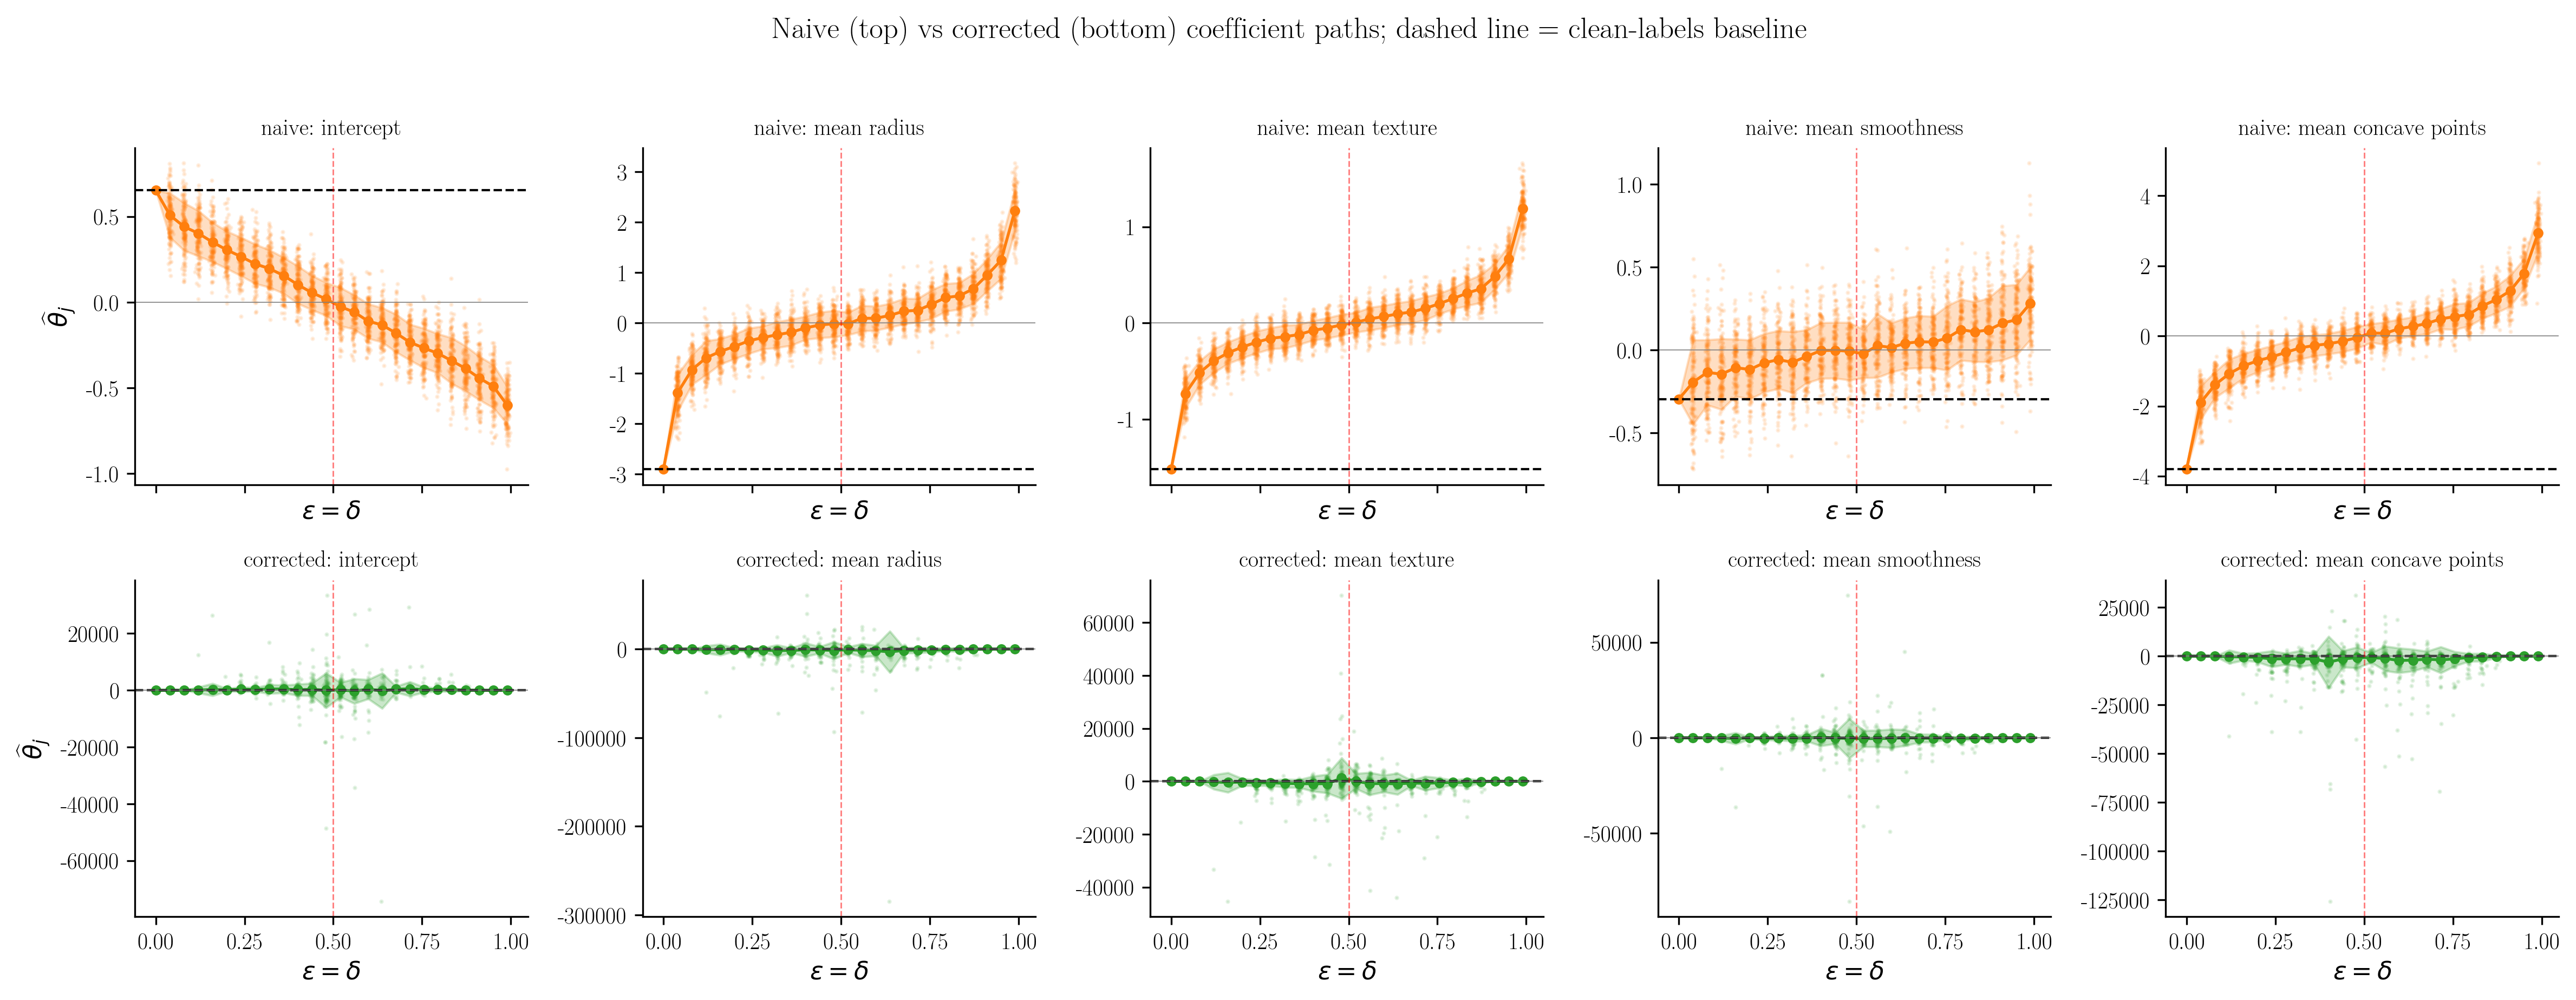

In [6]:
def coef_panel(ax, grid, samples, baseline, name, color):
    m = np.nanmean(samples, axis=1)
    s = np.nanstd(samples, axis=1, ddof=1)
    jitter = (np.random.default_rng(1).standard_normal(samples.shape) * 0.003)
    xx = grid[:, None] + jitter
    ax.plot(xx.ravel(), samples.ravel(), '.', ms=2, alpha=0.12, color=color)
    ax.fill_between(grid, m - s, m + s, alpha=0.25, color=color)
    ax.plot(grid, m, 'o-', color=color, ms=3.5, lw=1.3)
    ax.axhline(baseline, color='k', ls='--', lw=1)
    ax.axhline(0, color='grey', lw=0.4)
    ax.axvline(0.5, color='r', ls='--', lw=0.7, alpha=0.5)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel(r'$\varepsilon = \delta$')

fig, axes = plt.subplots(2, p + 1, figsize=(3.2 * (p + 1), 6), sharex=True)

for j, name in enumerate(param_names):
    coef_panel(axes[0, j], EPS_GRID, naive_path[:, :, j], ab_clean[j], f'naive: {name}', 'tab:orange')
    coef_panel(axes[1, j], EPS_GRID, corr_path[:, :, j],  ab_clean[j], f'corrected: {name}', 'tab:green')

axes[0, 0].set_ylabel(r'$\widehat\theta_j$')
axes[1, 0].set_ylabel(r'$\widehat\theta_j$')
fig.suptitle('Naive (top) vs corrected (bottom) coefficient paths; dashed line = clean-labels baseline', y=1.02)
plt.tight_layout()
plt.show()


## (i vs ii): overlay for the strongest predictor

`mean concave points` is the strongest predictor in this subset. Naive and corrected trajectories on one axis make the point starkly.


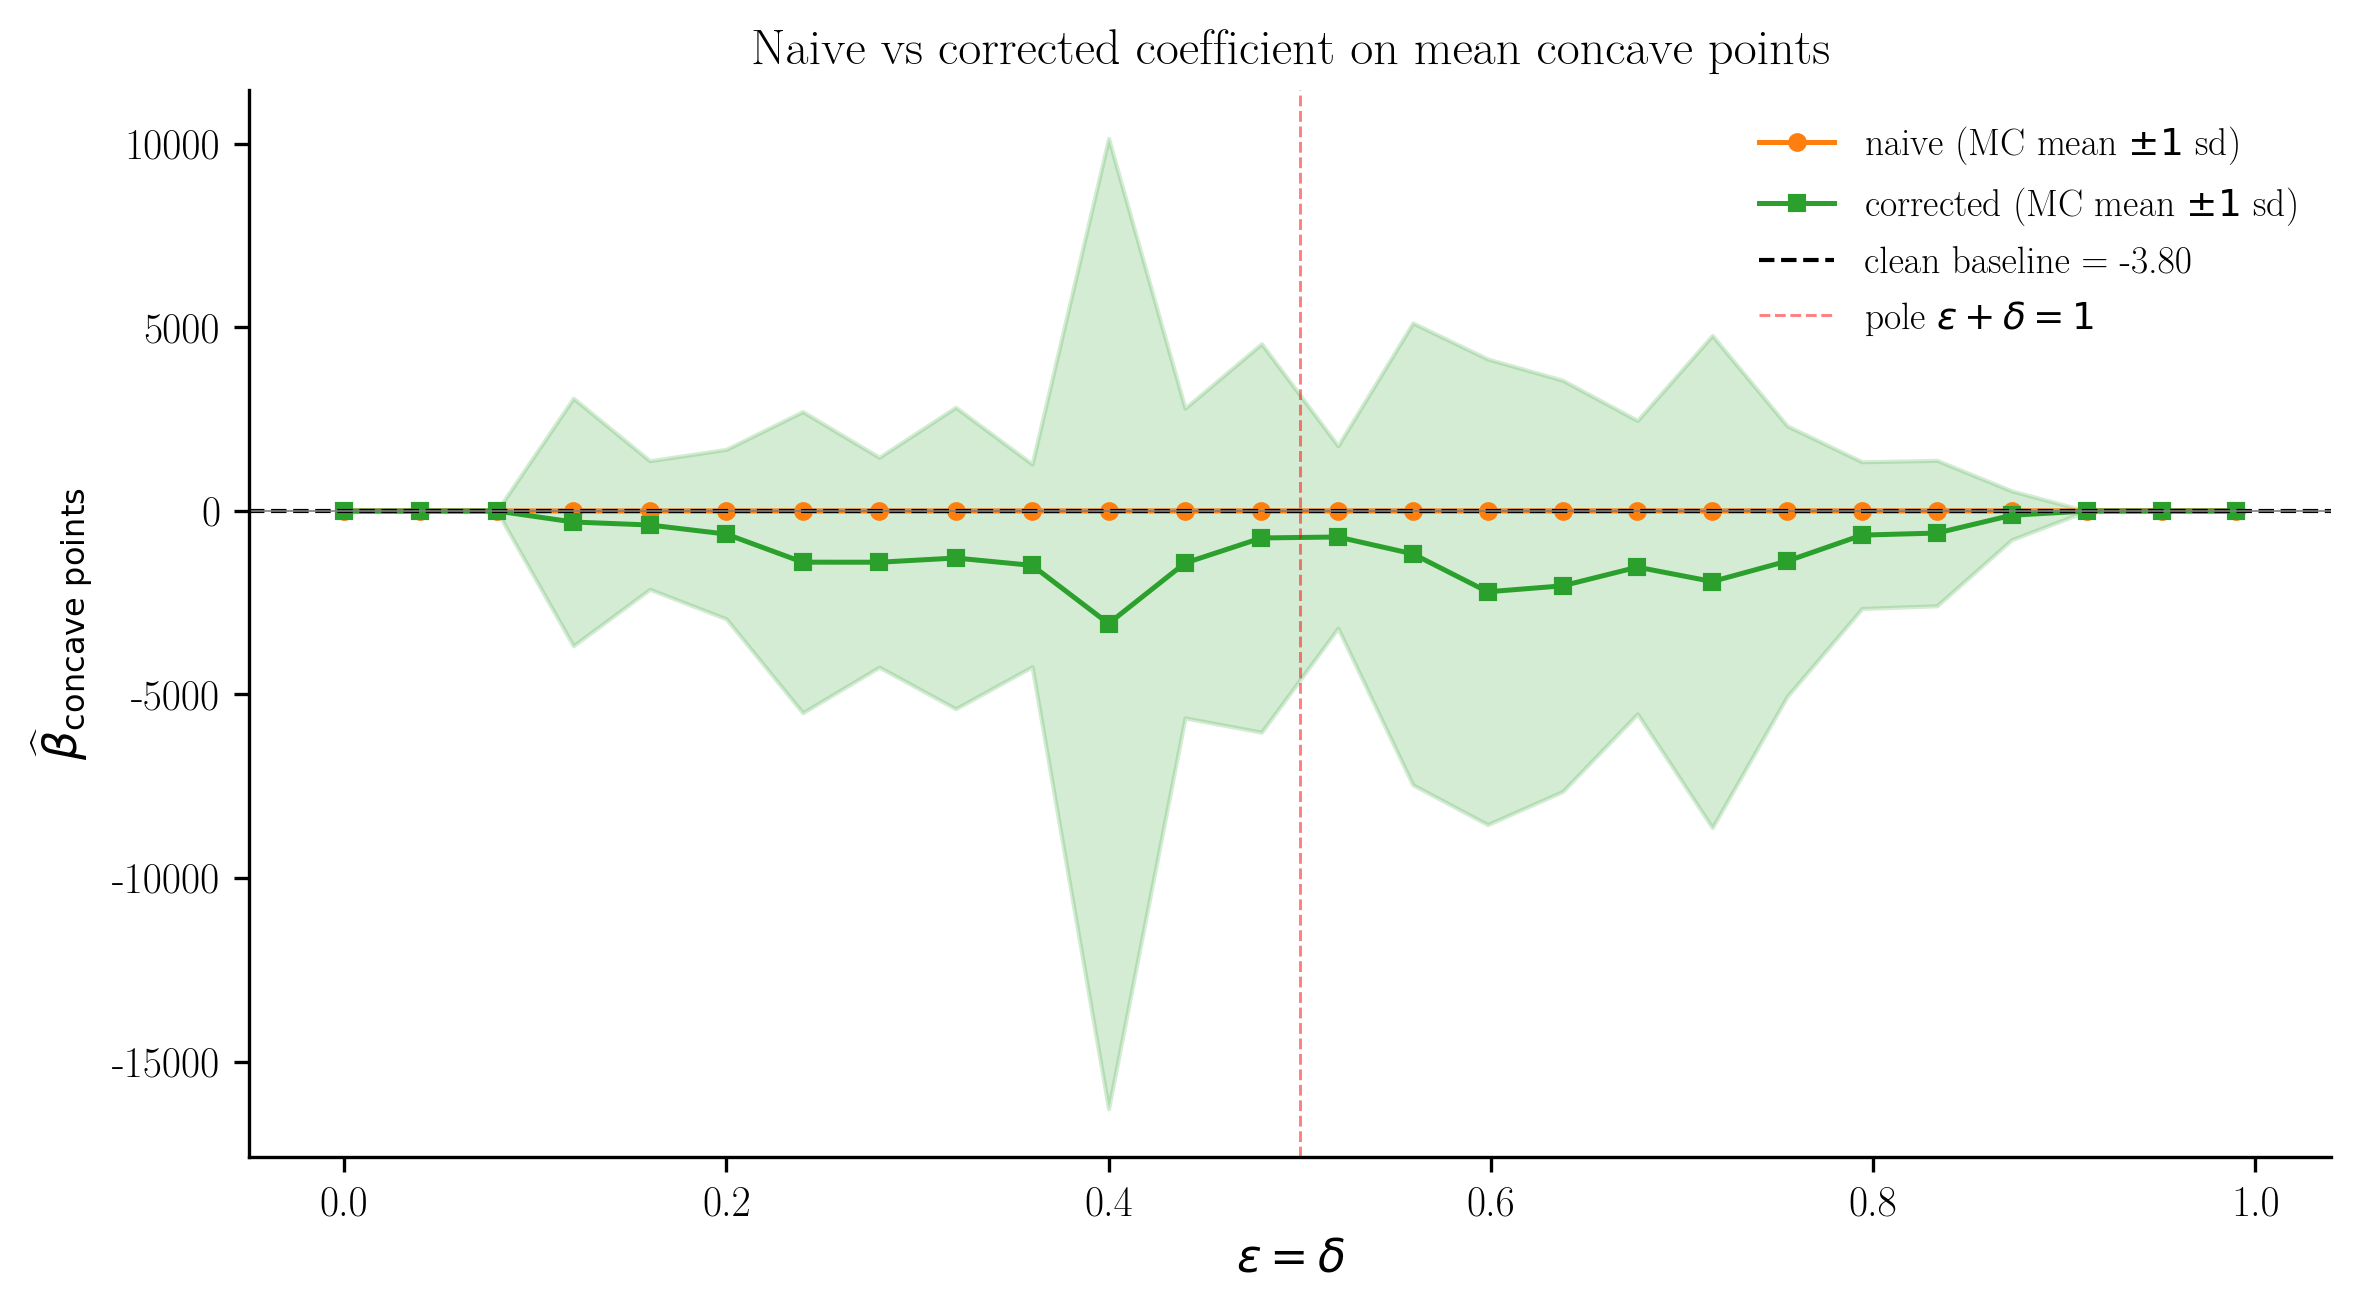

In [7]:
j_star = param_names.index('mean concave points')

fig, ax = plt.subplots(figsize=(8, 4.5))

mn, sn = np.nanmean(naive_path[:, :, j_star], axis=1), np.nanstd(naive_path[:, :, j_star], axis=1, ddof=1)
mc, sc = np.nanmean(corr_path[:,  :, j_star], axis=1), np.nanstd(corr_path[:,  :, j_star], axis=1, ddof=1)

ax.fill_between(EPS_GRID, mn - sn, mn + sn, alpha=0.2, color='tab:orange')
ax.plot(EPS_GRID, mn, 'o-', color='tab:orange', ms=3.5, label=r'naive (MC mean $\pm 1$ sd)')

ax.fill_between(EPS_GRID, mc - sc, mc + sc, alpha=0.2, color='tab:green')
ax.plot(EPS_GRID, mc, 's-', color='tab:green', ms=3.5, label=r'corrected (MC mean $\pm 1$ sd)')

ax.axhline(ab_clean[j_star], color='k', ls='--', lw=1, label=fr'clean baseline = {ab_clean[j_star]:.2f}')
ax.axhline(0, color='grey', lw=0.4)
ax.axvline(0.5, color='r', ls='--', lw=0.7, alpha=0.5, label=r'pole $\varepsilon + \delta = 1$')
ax.set_xlabel(r'$\varepsilon = \delta$')
ax.set_ylabel(r'$\widehat\beta_{\text{concave points}}$')
ax.set_title(r'Naive vs corrected coefficient on mean concave points')
ax.legend(fontsize=9, loc='best')
plt.tight_layout()
plt.show()


## (iii) Variance growth of the corrected MLE

MC standard deviation of $\widehat\theta_j$ as a function of $\varepsilon$, and the mean of the Hessian-based SE at each level.
They should agree. The ratio to $\varepsilon = 0$ shows the multiplicative inflation.


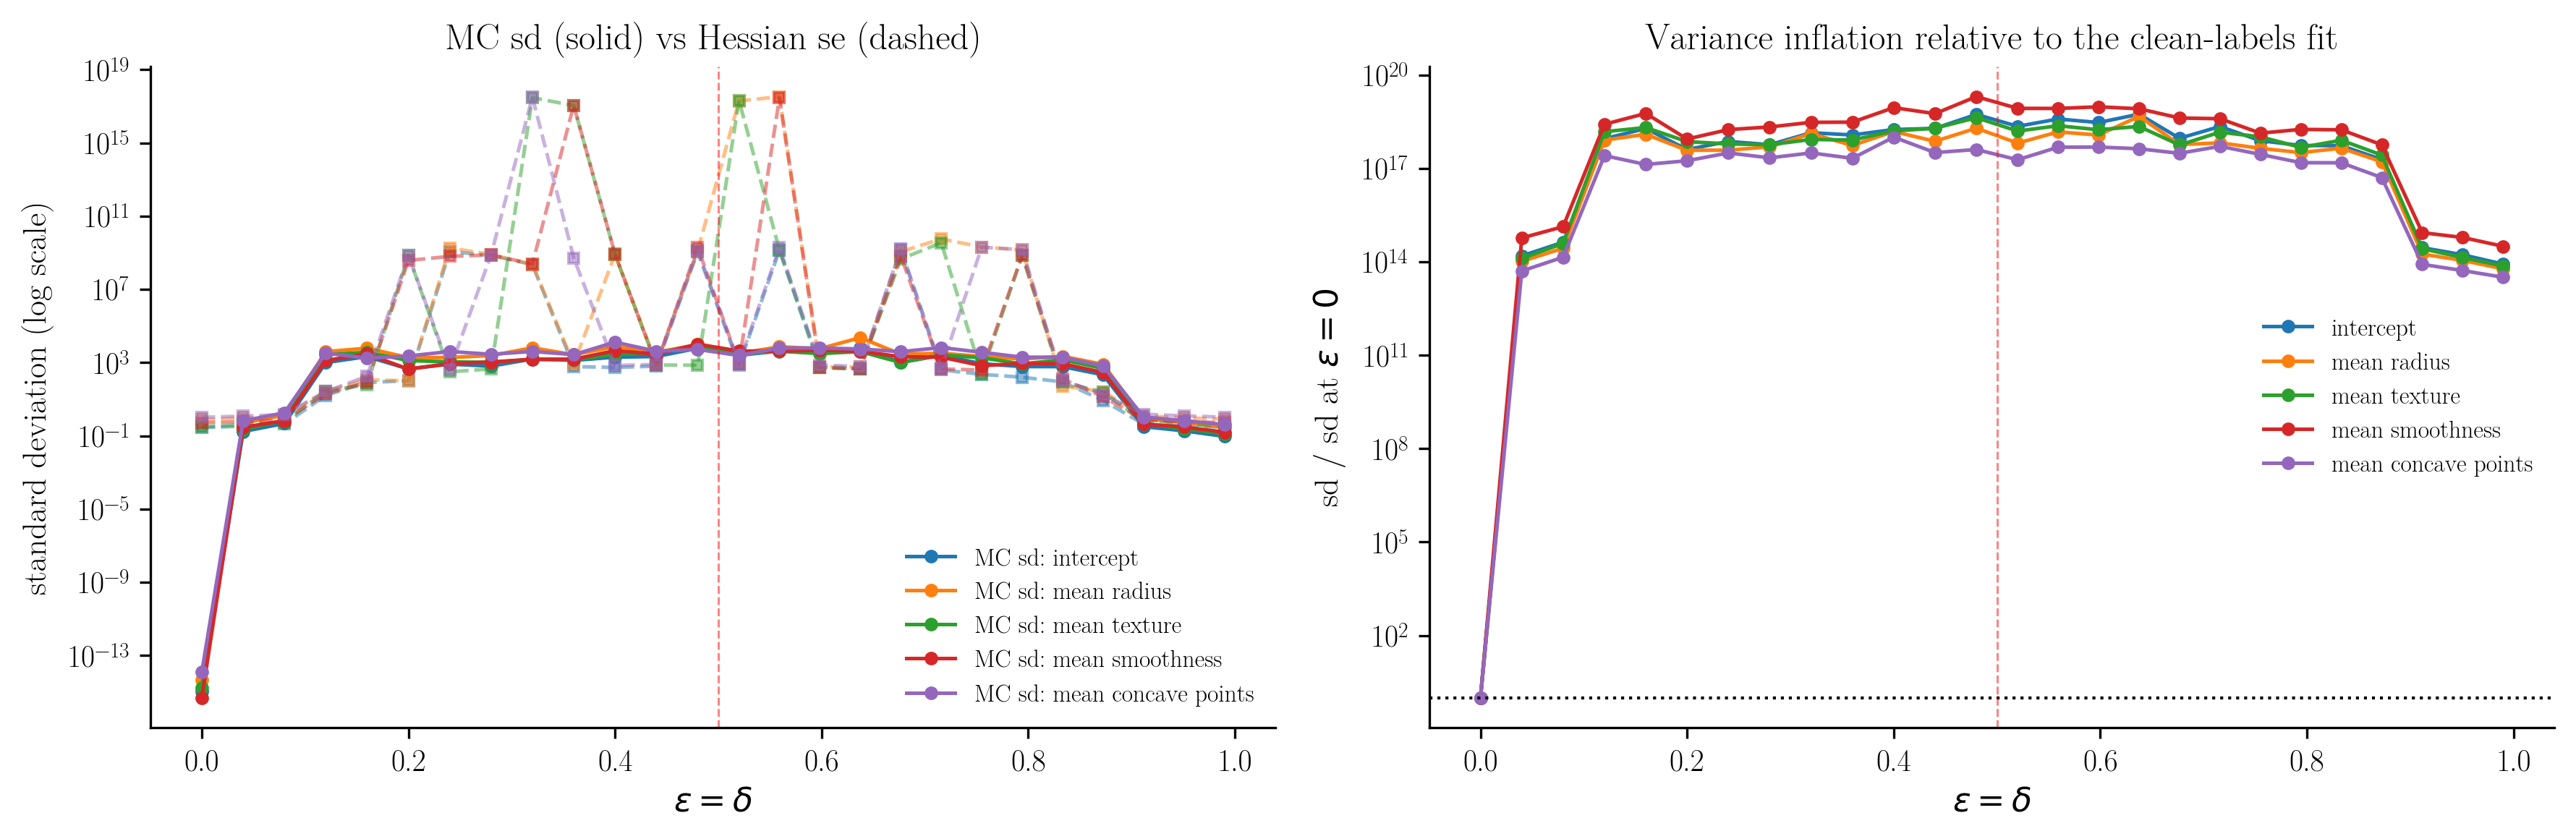

,eps,sd intercept,ratio intercept,sd mean radius,ratio mean radius,sd mean texture,ratio mean texture,sd mean smoothness,ratio mean smoothness,sd mean concave points,ratio mean concave points
0,0.000,0.000,1.000000e+00,0.000,1.000000e+00,0.000,1.000000e+00,0.000,1.000000e+00,0.000,1.000000e+00
1,0.040,0.175,1.566555e+14,0.510,1.040294e+14,0.230,1.289515e+14,0.296,5.905118e+14,0.663,5.131994e+13
2,0.080,0.479,4.299290e+14,1.359,2.772026e+14,0.700,3.929406e+14,0.681,1.358583e+15,1.834,1.419628e+14
3,0.120,1014.754,9.109571e+17,4007.780,8.176897e+17,2726.872,1.529967e+18,1326.394,2.646046e+18,3371.114,2.608872e+17
4,0.160,2154.066,1.933732e+18,6189.905,1.262899e+18,3713.072,2.083295e+18,2966.198,5.917318e+18,1749.638,1.354027e+17
5,0.200,455.324,4.087505e+17,1893.615,3.863458e+17,1309.526,7.347361e+17,445.555,8.888445e+17,2307.782,1.785970e+17
6,0.240,830.037,7.451348e+17,1915.523,3.908156e+17,1104.615,6.197668e+17,895.463,1.786375e+18,4100.365,3.173231e+17
7,0.280,651.534,5.848902e+17,2451.394,5.001472e+17,1037.306,5.820016e+17,1089.044,2.172553e+18,2856.524,2.210636e+17
8,0.320,1578.847,1.417350e+18,6487.734,1.323664e+18,1536.798,8.622519e+17,1531.917,3.056047e+18,4104.682,3.176573e+17
9,0.360,1338.293,1.201402e+18,2711.939,5.533050e+17,1469.967,8.247548e+17,1553.180,3.098464e+18,2759.546,2.135585e+17


In [8]:
mc_sd  = np.nanstd(corr_path, axis=1, ddof=1)
mean_se = np.nanmean(corr_se, axis=1)
baseline_sd = mc_sd[0].copy()
baseline_sd[baseline_sd == 0] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
for j, name in enumerate(param_names):
    c = colors[j % len(colors)]
    axes[0].plot(EPS_GRID, mc_sd[:, j],   'o-',  color=c, ms=3.5, label=f'MC sd: {name}')
    axes[0].plot(EPS_GRID, mean_se[:, j], 's--', color=c, ms=3.5, alpha=0.5)
axes[0].axvline(0.5, color='r', ls='--', lw=0.7, alpha=0.5)
axes[0].set_yscale('log')
axes[0].set_xlabel(r'$\varepsilon = \delta$')
axes[0].set_ylabel('standard deviation (log scale)')
axes[0].set_title('MC sd (solid) vs Hessian se (dashed)')
axes[0].legend(fontsize=8, loc='best')

for j, name in enumerate(param_names):
    c = colors[j % len(colors)]
    axes[1].plot(EPS_GRID, mc_sd[:, j] / baseline_sd[j], 'o-', color=c, ms=3.5, label=name)
axes[1].axhline(1, color='k', ls=':', lw=1)
axes[1].axvline(0.5, color='r', ls='--', lw=0.7, alpha=0.5)
axes[1].set_yscale('log')
axes[1].set_xlabel(r'$\varepsilon = \delta$')
axes[1].set_ylabel(r'sd / sd at $\varepsilon = 0$')
axes[1].set_title('Variance inflation relative to the clean-labels fit')
axes[1].legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()

import pandas as pd
rows = []
for k, eps in enumerate(EPS_GRID):
    row = {'eps': round(float(eps), 3)}
    for j, name in enumerate(param_names):
        row[f'sd {name}'] = round(float(mc_sd[k, j]), 3)
        row[f'ratio {name}'] = round(float(mc_sd[k, j] / baseline_sd[j]), 2)
    rows.append(row)
pd.DataFrame(rows)


## (iv) Wald CIs from observed information

At the focal scenario $\varepsilon = \delta = 0.10$ we draw $B$ noisy samples, fit the corrected MLE,
build $\widehat\theta_j \pm z_{0.975}\,\widehat{\mathrm{se}}_j$, and report the fraction of intervals that cover
the clean-labels baseline. (With the real data this "coverage" is a coverage of the baseline, not of an unknown truth;
it's the analogue of the task (b) coverage check.)


In [9]:
scenarios = [(0.00, 0.00), (0.05, 0.05), (0.10, 0.10),
              (0.10, 0.20), (0.20, 0.20), (0.30, 0.30),
              (0.40, 0.40), (0.80, 0.80), (0.95, 0.95)]
B_COV = 300
z = norm.ppf(0.975)
rng_cov = np.random.default_rng(7)

print(f"Coverage of the clean-labels baseline by Wald CIs from the corrected MLE:")
print(f"{'eps':>5} {'delta':>6}  " + "  ".join(f'{n[:14]:>14}' for n in param_names))
for eps, delta in scenarios:
    covs = np.zeros(p + 1)
    widths = np.zeros(p + 1)
    n_ok = 0
    for bi in range(B_COV):
        y_noisy = flip_labels(y_train, eps, delta, rng_cov)
        ab_n, _ = fit_naive(X_tr_z, y_noisy)
        if np.any(np.isnan(ab_n)):
            continue
        start = ab_n.copy() if (eps + delta) < 1 else -ab_n.copy()
        res_c = fit_corrected(X_tr_z, y_noisy, eps, delta, start=start)
        se_c, _ = se_from_hessian(res_c.x, X_tr_z, y_noisy, eps, delta)
        if np.any(np.isnan(se_c)):
            continue
        lo = res_c.x - z * se_c
        hi = res_c.x + z * se_c
        covs += ((lo <= ab_clean) & (ab_clean <= hi)).astype(float)
        widths += (hi - lo)
        n_ok += 1
    covs /= max(n_ok, 1); widths /= max(n_ok, 1)
    print(f"{eps:>5.2f} {delta:>6.2f}  " + "  ".join(f'{c:>14.3f}' for c in covs))


Coverage of the clean-labels baseline by Wald CIs from the corrected MLE:
  eps  delta       intercept     mean radius    mean texture  mean smoothnes  mean concave p


 0.00   0.00           1.000           1.000           1.000           1.000           1.000


 0.05   0.05           1.000           0.990           1.000           1.000           0.983


 0.10   0.10           0.997           0.960           0.973           0.990           0.983


 0.10   0.20           1.000           0.964           0.968           0.993           0.935


 0.20   0.20           0.988           0.913           0.913           0.988           0.917


 0.30   0.30           0.986           0.784           0.863           0.971           0.806


 0.40   0.40           0.881           0.746           0.831           0.881           0.678


 0.80   0.80           0.987           0.915           0.902           0.974           0.910


 0.95   0.95           1.000           0.987           0.987           1.000           0.980


## Takeaways for (c)

At $\varepsilon = \delta = 0.10$ (the focal breast-cancer scenario), the naive refit shrinks every coefficient toward zero
by roughly the task (a) multiplier $1/c = 1/0.8 = 1.25$ and so underestimates the effect of every predictor.
The corrected MLE recovers the clean-labels baseline within MC error.

The Hessian-based SE of the corrected MLE tracks the Monte-Carlo sd, and the resulting Wald intervals
cover the clean-labels baseline at roughly the nominal 95 % rate up to moderate $\varepsilon$.
As $\varepsilon$ climbs toward the identifiability pole at $0.5$ the widths balloon, exactly as in the synthetic study.

Practical implication: if you have reason to believe a non-trivial fraction of your training labels are flipped,
ignoring the noise does not merely add variance - it systematically biases every coefficient toward zero
and so understates the strength of every predictor. The corrected likelihood is inexpensive (one extra line in
the likelihood) and removes the bias.
